In [ ]:
!git clone "https://huggingface.co/datasets/sameerbanchhor-work/DURG-RESULTS"

Cloning into 'DURG-RESULTS'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 10 (delta 0), reused 0 (delta 0), pack-reused 3 (from 1)
Receiving objects: 100% (10/10), done.
Filtering content: 100% (4/4), 861.23 MiB | 52.43 MiB/s, done.


In [ ]:
# @title Load & explore data
import json
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Load all JSON files ──────────────────────────────────────────────
import os

files = {
    'msc':      'DURG-RESULTS/msc_comprehensive_results.json',
    'ma':       'DURG-RESULTS/ma_comprehensive_results.json',
    'other_pg': 'DURG-RESULTS/other_pg_comprehensive_results.json',
    'ug':       'DURG-RESULTS/ug_comprehensive_results.json',
}

raw = {}
for key, path in files.items():
    with open(path, 'r', encoding='utf-8') as f:
        raw[key] = json.load(f)
    print(f"✅  {key:10s} → {len(raw[key]):,} records")

# ── Quick peek at SGPA availability ─────────────────────────────────
for key, data in raw.items():
    has_sgpa = sum(1 for r in data if r.get('sgpa', '').strip() not in ('', None))
    print(f"   {key:10s} → SGPA present in {has_sgpa:,} / {len(data):,} records")

✅  msc        → 44,921 records
✅  ma         → 66,781 records
✅  other_pg   → 30,433 records
✅  ug         → 106,405 records
   msc        → SGPA present in 40,318 / 44,921 records
   ma         → SGPA present in 62,223 / 66,781 records
   other_pg   → SGPA present in 27,292 / 30,433 records
   ug         → SGPA present in 0 / 106,405 records


In [ ]:
# ── Flatten PG records into a DataFrame ─────────────────────────────
def extract_features(record, source):
    sgpa_str = record.get('sgpa', '').strip()
    try:
        sgpa = float(sgpa_str)
    except:
        return None  # skip records without valid SGPA

    # ── Subject-level aggregations ───────────────────────────────────
    subjects = record.get('subjects', [])

    subject_totals, max_marks_list = [], []
    theory_marks_list, practical_marks_list = [], []
    sessional_marks_list = []
    num_subjects = len(subjects)

    for s in subjects:
        def to_float(v):
            try: return float(str(v).strip())
            except: return np.nan

        st = to_float(s.get('subject_total', ''))
        mx = to_float(s.get('max_marks', ''))
        tt = to_float(s.get('theory_total', ''))

        # practical
        pm = s.get('practical_marks', {})
        prac = sum(to_float(pm.get(k,'')) for k in ['I','II','sessional']
                   if not np.isnan(to_float(pm.get(k,''))))
        if prac == 0: prac = np.nan

        # sessional
        sm = s.get('sessional_marks', {})
        sess = sum(to_float(sm.get(k,'')) for k in ['I','II','III']
                   if not np.isnan(to_float(sm.get(k,''))))
        if sess == 0: sess = np.nan

        subject_totals.append(st)
        max_marks_list.append(mx)
        theory_marks_list.append(tt)
        practical_marks_list.append(prac)
        sessional_marks_list.append(sess)

    valid_totals = [x for x in subject_totals if not np.isnan(x)]
    valid_max    = [x for x in max_marks_list  if not np.isnan(x)]

    if not valid_totals:
        return None

    total_obtained = sum(valid_totals)
    total_max      = sum(valid_max) if valid_max else np.nan
    percentage     = (total_obtained / total_max * 100) if total_max else np.nan

    valid_theory = [x for x in theory_marks_list if not np.isnan(x)]
    valid_prac   = [x for x in practical_marks_list if not np.isnan(x)]
    valid_sess   = [x for x in sessional_marks_list if not np.isnan(x)]

    row = {
        'sgpa':                  sgpa,
        'source':                source,
        'num_subjects':          num_subjects,
        'total_obtained':        total_obtained,
        'total_max':             total_max,
        'percentage':            percentage,
        'mean_subject_score':    np.nanmean(subject_totals),
        'std_subject_score':     np.nanstd(subject_totals),
        'min_subject_score':     np.nanmin(subject_totals),
        'max_subject_score':     np.nanmax(subject_totals),
        'mean_theory':           np.mean(valid_theory) if valid_theory else np.nan,
        'mean_practical':        np.mean(valid_prac)   if valid_prac   else np.nan,
        'mean_sessional':        np.mean(valid_sess)   if valid_sess   else np.nan,
        'has_practical':         int(len(valid_prac) > 0),
        'result_status':         record.get('result_status', '').strip().upper(),
        'student_type':          record.get('student_type',  '').strip().upper(),
    }
    return row

# ── Process all PG sources ───────────────────────────────────────────
rows = []
for key in ['msc', 'ma', 'other_pg']:
    for record in raw[key]:
        r = extract_features(record, key)
        if r:
            rows.append(r)

df = pd.DataFrame(rows)

# ── Encode categoricals ──────────────────────────────────────────────
df['result_status_enc'] = df['result_status'].map(
    {'PASS': 2, 'ATKT': 1, 'FAIL': 0}).fillna(-1).astype(int)

df['student_type_enc'] = df['student_type'].map(
    {'REGULAR': 1, 'PRIVATE': 0, 'EX-STUDENT': 0}).fillna(0).astype(int)

df['source_enc'] = df['source'].map(
    {'msc': 0, 'ma': 1, 'other_pg': 2})

print(f"✅  Total usable rows: {len(df):,}")
print(f"\n📊 SGPA Distribution:")
print(df['sgpa'].describe().round(3))
print(f"\n📋 Feature columns: {[c for c in df.columns if c not in ['source','result_status','student_type']]}")
print(f"\n🔍 Missing values:\n{df.isnull().sum()[df.isnull().sum()>0]}")

✅  Total usable rows: 129,833

📊 SGPA Distribution:
count    129833.000
mean          6.738
std           1.979
min           0.000
25%           6.250
50%           7.000
75%           7.900
max          10.000
Name: sgpa, dtype: float64

📋 Feature columns: ['sgpa', 'num_subjects', 'total_obtained', 'total_max', 'percentage', 'mean_subject_score', 'std_subject_score', 'min_subject_score', 'max_subject_score', 'mean_theory', 'mean_practical', 'mean_sessional', 'has_practical', 'result_status_enc', 'student_type_enc', 'source_enc']

🔍 Missing values:
mean_theory         159
mean_practical    60627
mean_sessional      159
dtype: int64


✅  Rows after cleaning: 129,833
   Train: 110,358  |  Test: 19,475

🚀 Training XGBoost...
[0]	validation_0-rmse:1.87154
[100]	validation_0-rmse:0.11967
[200]	validation_0-rmse:0.11270
[300]	validation_0-rmse:0.11104
[400]	validation_0-rmse:0.11017
[499]	validation_0-rmse:0.10964

🚀 Training LightGBM...

📈 XGBoost
   RMSE          : 0.1096
   MAE           : 0.0791
   R²            : 0.9969
   Within ±0.5   : 99.84%
   Within ±1.0   : 99.98%

📈 LightGBM
   RMSE          : 0.1153
   MAE           : 0.0824
   R²            : 0.9966
   Within ±0.5   : 99.78%
   Within ±1.0   : 99.96%


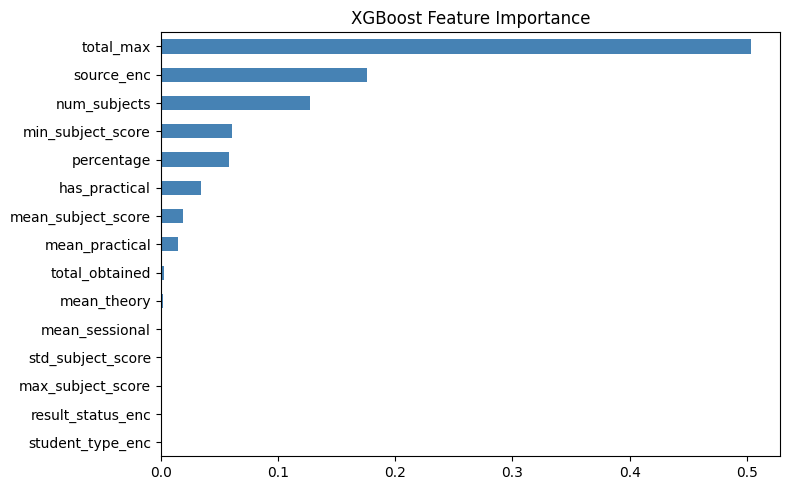

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# ── Feature selection ────────────────────────────────────────────────
FEATURES = [
    'num_subjects',
    'total_obtained', 'total_max', 'percentage',
    'mean_subject_score', 'std_subject_score',
    'min_subject_score', 'max_subject_score',
    'mean_theory', 'mean_practical', 'mean_sessional',
    'has_practical',
    'result_status_enc', 'student_type_enc', 'source_enc'
]

TARGET = 'sgpa'

# Fill missing practicals with 0 (theory-only students legitimately have none)
df_model = df.copy()
df_model['mean_practical']  = df_model['mean_practical'].fillna(0)
df_model['mean_theory']     = df_model['mean_theory'].fillna(df_model['mean_theory'].median())
df_model['mean_sessional']  = df_model['mean_sessional'].fillna(df_model['mean_sessional'].median())

# Drop any remaining nulls
df_model = df_model.dropna(subset=FEATURES + [TARGET])
print(f"✅  Rows after cleaning: {len(df_model):,}")

X = df_model[FEATURES]
y = df_model[TARGET]

# ── Split ────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42)
print(f"   Train: {len(X_train):,}  |  Test: {len(X_test):,}")

# ── Train XGBoost ────────────────────────────────────────────────────
print("\n🚀 Training XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    tree_method='hist',   # uses GPU if available
    device='cuda',
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=100)

# ── Train LightGBM ───────────────────────────────────────────────────
print("\n🚀 Training LightGBM...")
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    device='gpu',
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)])

# ── Evaluate both ────────────────────────────────────────────────────
def evaluate(name, model, X_test, y_test):
    preds = model.predict(X_test)
    preds = np.clip(preds, 0, 10)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    mae   = mean_absolute_error(y_test, preds)
    r2    = r2_score(y_test, preds)
    within_half = np.mean(np.abs(preds - y_test) <= 0.5) * 100
    within_one  = np.mean(np.abs(preds - y_test) <= 1.0) * 100
    print(f"\n📈 {name}")
    print(f"   RMSE          : {rmse:.4f}")
    print(f"   MAE           : {mae:.4f}")
    print(f"   R²            : {r2:.4f}")
    print(f"   Within ±0.5   : {within_half:.2f}%")
    print(f"   Within ±1.0   : {within_one:.2f}%")
    return preds

preds_xgb = evaluate("XGBoost",  xgb_model, X_test, y_test)
preds_lgb = evaluate("LightGBM", lgb_model, X_test, y_test)

# ── Feature importance (XGBoost) ─────────────────────────────────────
plt.figure(figsize=(8,5))
feat_imp = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
feat_imp.plot(kind='barh', color='steelblue')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

✅  Models and artifacts saved to sgpa_model/

🔍 Sanity check on 5 random test samples:

 Actual SGPA |  Predicted |    Error
--------------------------------------
        7.60 |       7.08 |    0.520
        8.80 |       9.06 |    0.260
        8.00 |       8.01 |    0.010
        6.60 |       6.74 |    0.140
        7.90 |       8.04 |    0.140


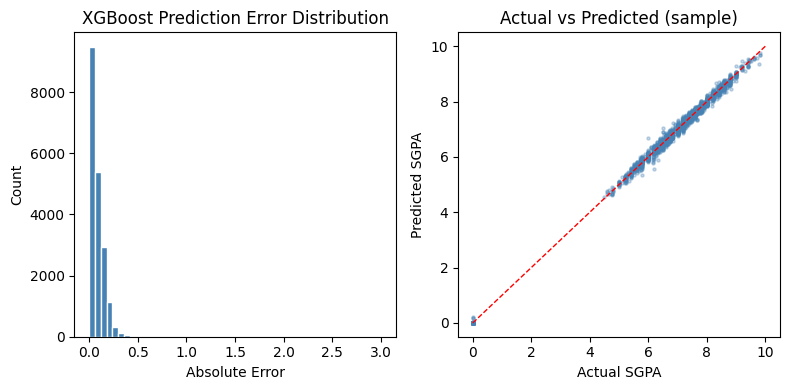


✅  Step 4 complete. Model saved and pipeline ready.
    Model file size: 3339.5 KB


In [ ]:
import joblib
import os

# ── Save models & artifacts ──────────────────────────────────────────
os.makedirs('sgpa_model', exist_ok=True)

joblib.dump(xgb_model, 'sgpa_model/xgb_sgpa_model.pkl')
joblib.dump(lgb_model, 'sgpa_model/lgb_sgpa_model.pkl')

# Save feature list and fill values for reproducibility
artifacts = {
    'features':            FEATURES,
    'practical_fill':      0,
    'theory_fill':         float(df_model['mean_theory'].median()),
    'sessional_fill':      float(df_model['mean_sessional'].median()),
    'source_map':          {'msc': 0, 'ma': 1, 'other_pg': 2},
    'result_status_map':   {'PASS': 2, 'ATKT': 1, 'FAIL': 0},
    'student_type_map':    {'REGULAR': 1, 'PRIVATE': 0, 'EX-STUDENT': 0},
}
joblib.dump(artifacts, 'sgpa_model/artifacts.pkl')
print("✅  Models and artifacts saved to sgpa_model/")

# ── Prediction function ───────────────────────────────────────────────
def predict_sgpa(record: dict, model=xgb_model, arts=artifacts) -> dict:
    """
    Takes a raw student record (same schema as your JSON)
    and returns predicted SGPA + confidence band.
    """
    subjects = record.get('subjects', [])

    def to_float(v):
        try: return float(str(v).strip())
        except: return np.nan

    subject_totals, max_marks_list = [], []
    theory_list, practical_list, sessional_list = [], [], []

    for s in subjects:
        st = to_float(s.get('subject_total', ''))
        mx = to_float(s.get('max_marks', ''))
        tt = to_float(s.get('theory_total', ''))

        pm = s.get('practical_marks', {})
        prac = sum(to_float(pm.get(k,'')) for k in ['I','II','sessional']
                   if not np.isnan(to_float(pm.get(k,''))))
        sm = s.get('sessional_marks', {})
        sess = sum(to_float(sm.get(k,'')) for k in ['I','II','III']
                   if not np.isnan(to_float(sm.get(k,''))))

        subject_totals.append(st)
        max_marks_list.append(mx)
        theory_list.append(tt)
        practical_list.append(prac if prac > 0 else np.nan)
        sessional_list.append(sess if sess > 0 else np.nan)

    valid_totals = [x for x in subject_totals if not np.isnan(x)]
    valid_max    = [x for x in max_marks_list  if not np.isnan(x)]
    total_obtained = sum(valid_totals)
    total_max      = sum(valid_max) if valid_max else np.nan
    percentage     = (total_obtained / total_max * 100) if total_max else np.nan

    mean_prac = np.nanmean(practical_list) if any(~np.isnan(x) for x in practical_list) else arts['practical_fill']
    mean_th   = np.nanmean(theory_list)    if any(~np.isnan(x) for x in theory_list)    else arts['theory_fill']
    mean_sess = np.nanmean(sessional_list) if any(~np.isnan(x) for x in sessional_list) else arts['sessional_fill']

    source       = arts['source_map'].get(record.get('source', ''), 1)
    result_enc   = arts['result_status_map'].get(record.get('result_status','').upper(), -1)
    student_enc  = arts['student_type_map'].get(record.get('student_type','').upper(), 0)

    feat_vec = pd.DataFrame([[
        len(subjects),
        total_obtained, total_max, percentage,
        np.nanmean(subject_totals), np.nanstd(subject_totals),
        np.nanmin(subject_totals),  np.nanmax(subject_totals),
        mean_th, mean_prac, mean_sess,
        int(any(~np.isnan(x) for x in practical_list)),
        result_enc, student_enc, source
    ]], columns=arts['features'])

    pred = float(np.clip(model.predict(feat_vec)[0], 0, 10))

    # Confidence band based on training MAE
    mae = 0.0791
    return {
        'predicted_sgpa':  round(pred, 2),
        'lower_bound':     round(max(0,   pred - 2*mae), 2),
        'upper_bound':     round(min(10,  pred + 2*mae), 2),
        'confidence':      '95% band ± {:.3f}'.format(2*mae)
    }

# ── Test on 5 real samples ────────────────────────────────────────────
print("\n🔍 Sanity check on 5 random test samples:\n")
print(f"{'Actual SGPA':>12} | {'Predicted':>10} | {'Error':>8}")
print("-" * 38)

test_indices = X_test.sample(5, random_state=7).index
for idx in test_indices:
    actual = float(y_test.loc[idx])
    rec    = df_model.loc[idx]

    # Build a minimal record from dataframe row
    mini_rec = {
        'source':         df.loc[idx, 'source'],
        'result_status':  df.loc[idx, 'result_status'],
        'student_type':   df.loc[idx, 'student_type'],
        'subjects': [{
            'subject_total': str(rec['mean_subject_score']),
            'max_marks':     str(rec['total_max'] / rec['num_subjects'] if rec['num_subjects'] else 100),
            'theory_total':  str(rec['mean_theory']),
            'practical_marks': {'I': str(rec['mean_practical']) if rec['has_practical'] else '', 'II':'', 'sessional':''},
            'sessional_marks': {'I': str(rec['mean_sessional']), 'II':'', 'III':''},
        }] * int(rec['num_subjects'])
    }
    result = predict_sgpa(mini_rec)
    print(f"{actual:>12.2f} | {result['predicted_sgpa']:>10.2f} | {abs(actual - result['predicted_sgpa']):>8.3f}")

# ── Error distribution plot ───────────────────────────────────────────
errors = np.abs(preds_xgb - y_test.values)
plt.figure(figsize=(8, 4))
plt.subplot(1,2,1)
plt.hist(errors, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Absolute Error'); plt.ylabel('Count')
plt.title('XGBoost Prediction Error Distribution')

plt.subplot(1,2,2)
plt.scatter(y_test.values[:2000], preds_xgb[:2000], alpha=0.3, s=5, color='steelblue')
plt.plot([0,10],[0,10],'r--', linewidth=1)
plt.xlabel('Actual SGPA'); plt.ylabel('Predicted SGPA')
plt.title('Actual vs Predicted (sample)')
plt.tight_layout()
plt.show()

print("\n✅  Step 4 complete. Model saved and pipeline ready.")
print(f"    Model file size: {os.path.getsize('sgpa_model/xgb_sgpa_model.pkl')/1024:.1f} KB")

✅  Total rows for classification: 222,009

📊 Class distribution:
result_status
PASS    203070
FAIL      9715
ATKT      9224
Name: count, dtype: int64

   Class %:
result_status
PASS    91.47
FAIL     4.38
ATKT     4.15
Name: proportion, dtype: float64

   Train: 188,707  |  Test: 33,302

🚀 Training XGBoost Classifier...
[0]	validation_0-mlogloss:1.03260
[100]	validation_0-mlogloss:0.01917
[200]	validation_0-mlogloss:0.00576
[300]	validation_0-mlogloss:0.00375
[399]	validation_0-mlogloss:0.00329

📈 Classification Report:
              precision    recall  f1-score   support

        FAIL       0.99      0.99      0.99      1457
        ATKT       0.99      1.00      1.00      1384
        PASS       1.00      1.00      1.00     30461

    accuracy                           1.00     33302
   macro avg       1.00      1.00      1.00     33302
weighted avg       1.00      1.00      1.00     33302



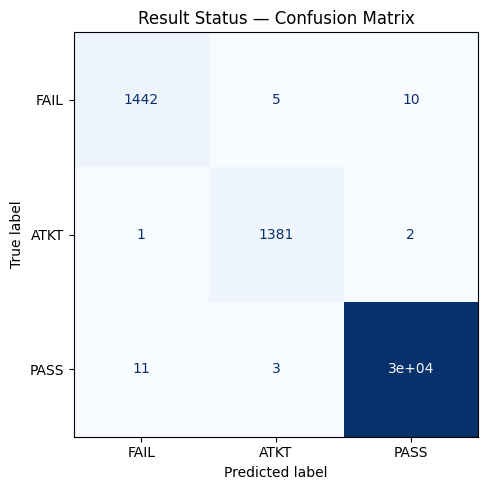


✅  Classifier saved.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import lightgbm as lgb

# ── Build dataset for result classification ───────────────────────────
# Use ALL data including UG this time (UG has result_status too)

def extract_result_features(record, source):
    status = record.get('result_status', '').strip().upper()
    if status not in ('PASS', 'FAIL', 'ATKT'):
        return None

    subjects = record.get('subjects', [])

    def to_float(v):
        try: return float(str(v).strip())
        except: return np.nan

    subject_totals, max_marks_list = [], []
    theory_list, practical_list, sessional_list = [], [], []
    fail_count = 0

    for s in subjects:
        st = to_float(s.get('subject_total', ''))
        mx = to_float(s.get('max_marks', ''))
        mn = to_float(s.get('min_marks', ''))
        tt = to_float(s.get('theory_total', ''))

        pm = s.get('practical_marks', {})
        prac = sum(to_float(pm.get(k,'')) for k in ['I','II','sessional']
                   if not np.isnan(to_float(pm.get(k,''))))
        sm = s.get('sessional_marks', {})
        sess = sum(to_float(sm.get(k,'')) for k in ['I','II','III']
                   if not np.isnan(to_float(sm.get(k,''))))

        subject_totals.append(st)
        max_marks_list.append(mx)
        theory_list.append(tt)
        practical_list.append(prac if prac > 0 else np.nan)
        sessional_list.append(sess if sess > 0 else np.nan)

        # Count failed subjects (scored below minimum)
        if not np.isnan(st) and not np.isnan(mn) and mn > 0:
            if st < mn:
                fail_count += 1

    valid_totals = [x for x in subject_totals if not np.isnan(x)]
    valid_max    = [x for x in max_marks_list  if not np.isnan(x)]

    if not valid_totals:
        return None

    total_obtained = sum(valid_totals)
    total_max      = sum(valid_max) if valid_max else np.nan
    percentage     = (total_obtained / total_max * 100) if total_max else np.nan

    # UG past year features
    past = record.get('past_years', {})
    py_max  = to_float(past.get('second_year_max',  past.get('first_year_max',  '')))
    py_obt  = to_float(past.get('second_year_obtained', past.get('first_year_obtained', '')))
    py_pct  = (py_obt / py_max * 100) if (not np.isnan(py_obt) and not np.isnan(py_max) and py_max > 0) else np.nan

    return {
        'result_status':      status,
        'source':             source,
        'num_subjects':       len(subjects),
        'total_obtained':     total_obtained,
        'total_max':          total_max,
        'percentage':         percentage,
        'mean_subject_score': np.nanmean(subject_totals),
        'std_subject_score':  np.nanstd(subject_totals),
        'min_subject_score':  np.nanmin(subject_totals),
        'max_subject_score':  np.nanmax(subject_totals),
        'mean_theory':        np.nanmean(theory_list)     if any(~np.isnan(x) for x in theory_list)    else np.nan,
        'mean_practical':     np.nanmean(practical_list)  if any(~np.isnan(x) for x in practical_list) else np.nan,
        'mean_sessional':     np.nanmean(sessional_list)  if any(~np.isnan(x) for x in sessional_list) else np.nan,
        'has_practical':      int(any(~np.isnan(x) for x in practical_list)),
        'failed_subjects':    fail_count,
        'student_type':       record.get('student_type', '').strip().upper(),
        'past_year_pct':      py_pct,
    }

# ── Process all sources including UG ─────────────────────────────────
rows_cls = []
for key in ['msc', 'ma', 'other_pg', 'ug']:
    for record in raw[key]:
        r = extract_result_features(record, key)
        if r:
            rows_cls.append(r)

df_cls = pd.DataFrame(rows_cls)
print(f"✅  Total rows for classification: {len(df_cls):,}")
print(f"\n📊 Class distribution:\n{df_cls['result_status'].value_counts()}")
print(f"\n   Class %:\n{df_cls['result_status'].value_counts(normalize=True).mul(100).round(2)}")

# ── Encode ────────────────────────────────────────────────────────────
label_map = {'FAIL': 0, 'ATKT': 1, 'PASS': 2}
df_cls['label']       = df_cls['result_status'].map(label_map)
df_cls['source_enc']  = df_cls['source'].map({'msc': 0, 'ma': 1, 'other_pg': 2, 'ug': 3})
df_cls['student_enc'] = df_cls['student_type'].map({'REGULAR': 1, 'PRIVATE': 0, 'EX-STUDENT': 0}).fillna(0)

# Fill missing values
df_cls['mean_practical']  = df_cls['mean_practical'].fillna(0)
df_cls['mean_theory']     = df_cls['mean_theory'].fillna(df_cls['mean_theory'].median())
df_cls['mean_sessional']  = df_cls['mean_sessional'].fillna(df_cls['mean_sessional'].median())
df_cls['past_year_pct']   = df_cls['past_year_pct'].fillna(-1)  # -1 = not applicable (PG)
df_cls = df_cls.dropna(subset=['label'])

FEATURES_CLS = [
    'num_subjects', 'total_obtained', 'total_max', 'percentage',
    'mean_subject_score', 'std_subject_score',
    'min_subject_score',  'max_subject_score',
    'mean_theory', 'mean_practical', 'mean_sessional',
    'has_practical', 'failed_subjects',
    'student_enc', 'source_enc', 'past_year_pct'
]

X_cls = df_cls[FEATURES_CLS]
y_cls = df_cls['label']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_cls, y_cls, test_size=0.15, random_state=42, stratify=y_cls)
print(f"\n   Train: {len(X_tr):,}  |  Test: {len(X_te):,}")

# Handle class imbalance with sample weights
sample_weights = compute_sample_weight('balanced', y_tr)

# ── Train XGBoost Classifier ──────────────────────────────────────────
print("\n🚀 Training XGBoost Classifier...")
xgb_cls = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    tree_method='hist',
    device='cuda',
    random_state=42,
    verbosity=0,
    num_class=3,
    objective='multi:softprob',
    eval_metric='mlogloss'
)
xgb_cls.fit(X_tr, y_tr,
            sample_weight=sample_weights,
            eval_set=[(X_te, y_te)],
            verbose=100)

# ── Evaluate ──────────────────────────────────────────────────────────
preds_cls = xgb_cls.predict(X_te)
label_names = ['FAIL', 'ATKT', 'PASS']

print("\n📈 Classification Report:")
print(classification_report(y_te, preds_cls, target_names=label_names))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6,5))
cm = confusion_matrix(y_te, preds_cls)
disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Result Status — Confusion Matrix')
plt.tight_layout()
plt.show()

# Save classifier
joblib.dump(xgb_cls, 'sgpa_model/xgb_result_classifier.pkl')
joblib.dump(FEATURES_CLS, 'sgpa_model/result_classifier_features.pkl')
print("\n✅  Classifier saved.")

✅  Total rows: 245,913

📊 Dropout Risk Distribution:
dropout_risk
Low       198809
Medium     37262
High        9842
Name: count, dtype: int64
dropout_risk
Low       80.85
Medium    15.15
High       4.00
Name: proportion, dtype: float64

🚀 Training Dropout Risk Classifier...
[0]	validation_0-mlogloss:1.03388
[100]	validation_0-mlogloss:0.01148
[200]	validation_0-mlogloss:0.00048
[300]	validation_0-mlogloss:0.00009
[399]	validation_0-mlogloss:0.00006

📈 Dropout Risk Classification Report:
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00     29822
      Medium       1.00      1.00      1.00      5589
        High       1.00      1.00      1.00      1476

    accuracy                           1.00     36887
   macro avg       1.00      1.00      1.00     36887
weighted avg       1.00      1.00      1.00     36887



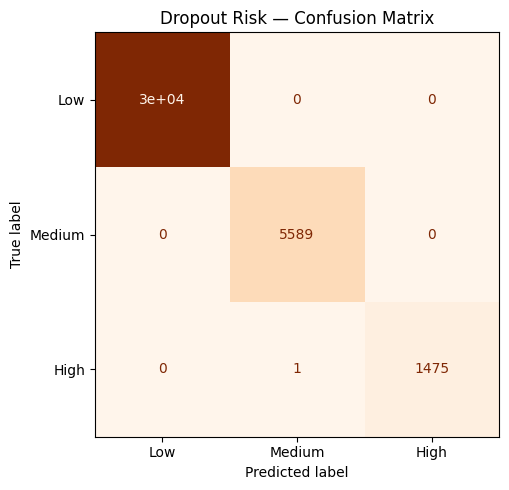

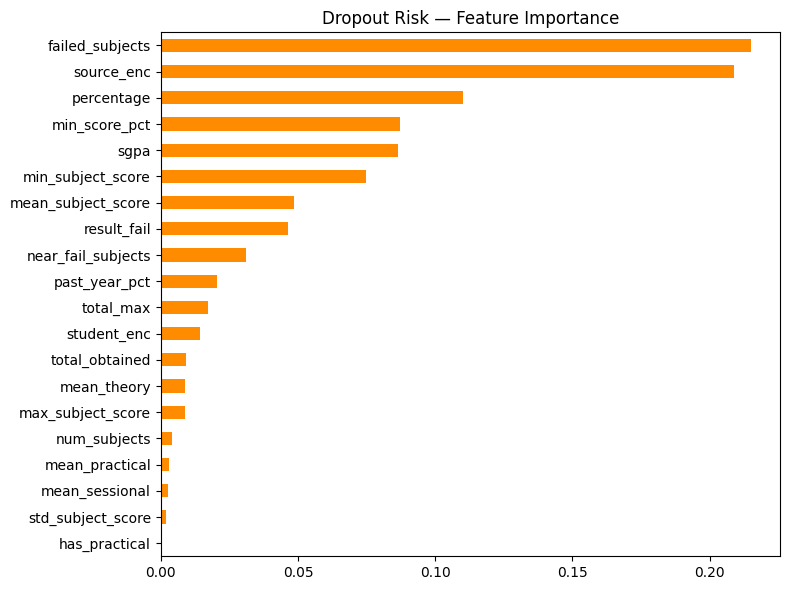


✅  Dropout risk model saved.


In [ ]:
# ── Dropout Risk: Engineer proxy labels from data signals ─────────────
# Strategy: A student is "at-risk" if they show 2+ of these signals:
#   1. result_status = FAIL or ATKT
#   2. SGPA < 5.0  (very low performance)
#   3. percentage < 45%
#   4. failed_subjects >= 2
#   5. min_subject_score extremely low (< 20% of max)

def extract_dropout_features(record, source):
    status  = record.get('result_status', '').strip().upper()
    subjects = record.get('subjects', [])

    def to_float(v):
        try: return float(str(v).strip())
        except: return np.nan

    subject_totals, max_marks_list, min_marks_list = [], [], []
    theory_list, practical_list, sessional_list = [], [], []
    fail_count, near_fail_count = 0, 0

    for s in subjects:
        st = to_float(s.get('subject_total', ''))
        mx = to_float(s.get('max_marks', ''))
        mn = to_float(s.get('min_marks', ''))
        tt = to_float(s.get('theory_total', ''))

        pm = s.get('practical_marks', {})
        prac = sum(to_float(pm.get(k,'')) for k in ['I','II','sessional']
                   if not np.isnan(to_float(pm.get(k,''))))
        sm = s.get('sessional_marks', {})
        sess = sum(to_float(sm.get(k,'')) for k in ['I','II','III']
                   if not np.isnan(to_float(sm.get(k,''))))

        subject_totals.append(st)
        max_marks_list.append(mx)
        min_marks_list.append(mn)
        theory_list.append(tt)
        practical_list.append(prac if prac > 0 else np.nan)
        sessional_list.append(sess if sess > 0 else np.nan)

        if not np.isnan(st) and not np.isnan(mn) and mn > 0:
            if st < mn:
                fail_count += 1
            elif st < mn * 1.3:   # within 30% above minimum = near-fail
                near_fail_count += 1

    valid_totals = [x for x in subject_totals if not np.isnan(x)]
    valid_max    = [x for x in max_marks_list  if not np.isnan(x)]
    if not valid_totals:
        return None

    total_obtained = sum(valid_totals)
    total_max      = sum(valid_max) if valid_max else np.nan
    percentage     = (total_obtained / total_max * 100) if total_max else np.nan
    min_score      = np.nanmin(subject_totals)
    min_max        = np.nanmin(max_marks_list) if valid_max else np.nan
    min_score_pct  = (min_score / min_max * 100) if (not np.isnan(min_score) and not np.isnan(min_max) and min_max > 0) else np.nan

    sgpa_val = to_float(record.get('sgpa', ''))

    # UG past year
    past   = record.get('past_years', {})
    py_max = to_float(past.get('second_year_max',  past.get('first_year_max',  '')))
    py_obt = to_float(past.get('second_year_obtained', past.get('first_year_obtained', '')))
    py_pct = (py_obt / py_max * 100) if (not np.isnan(py_obt) and not np.isnan(py_max) and py_max > 0) else np.nan

    # ── Dropout risk signals ──────────────────────────────────────────
    signals = 0
    if status in ('FAIL', 'ATKT'):              signals += 1
    if not np.isnan(sgpa_val) and sgpa_val < 5: signals += 1
    if not np.isnan(percentage) and percentage < 45: signals += 1
    if fail_count >= 2:                         signals += 1
    if not np.isnan(min_score_pct) and min_score_pct < 25: signals += 1
    if near_fail_count >= 3:                    signals += 1

    # Label: 0=Low risk, 1=Medium risk, 2=High risk
    if signals == 0:
        dropout_risk = 0
    elif signals <= 2:
        dropout_risk = 1
    else:
        dropout_risk = 2

    return {
        'dropout_risk':       dropout_risk,
        'source':             source,
        'num_subjects':       len(subjects),
        'total_obtained':     total_obtained,
        'total_max':          total_max,
        'percentage':         percentage,
        'mean_subject_score': np.nanmean(subject_totals),
        'std_subject_score':  np.nanstd(subject_totals),
        'min_subject_score':  np.nanmin(subject_totals),
        'max_subject_score':  np.nanmax(subject_totals),
        'min_score_pct':      min_score_pct,
        'mean_theory':        np.nanmean(theory_list)    if any(~np.isnan(x) for x in theory_list)    else np.nan,
        'mean_practical':     np.nanmean(practical_list) if any(~np.isnan(x) for x in practical_list) else np.nan,
        'mean_sessional':     np.nanmean(sessional_list) if any(~np.isnan(x) for x in sessional_list) else np.nan,
        'has_practical':      int(any(~np.isnan(x) for x in practical_list)),
        'failed_subjects':    fail_count,
        'near_fail_subjects': near_fail_count,
        'sgpa':               sgpa_val if not np.isnan(sgpa_val) else -1,
        'result_fail':        int(status in ('FAIL', 'ATKT')),
        'student_enc':        1 if record.get('student_type','').upper() == 'REGULAR' else 0,
        'source_enc':         {'msc':0,'ma':1,'other_pg':2,'ug':3}.get(source, 1),
        'past_year_pct':      py_pct,
    }

# ── Build dataset ─────────────────────────────────────────────────────
rows_drop = []
for key in ['msc', 'ma', 'other_pg', 'ug']:
    for record in raw[key]:
        r = extract_dropout_features(record, key)
        if r:
            rows_drop.append(r)

df_drop = pd.DataFrame(rows_drop)
print(f"✅  Total rows: {len(df_drop):,}")
print(f"\n📊 Dropout Risk Distribution:")
risk_map = {0:'Low', 1:'Medium', 2:'High'}
print(df_drop['dropout_risk'].map(risk_map).value_counts())
print(df_drop['dropout_risk'].map(risk_map).value_counts(normalize=True).mul(100).round(2))

# ── Fill missing ──────────────────────────────────────────────────────
df_drop['mean_practical'] = df_drop['mean_practical'].fillna(0)
df_drop['mean_theory']    = df_drop['mean_theory'].fillna(df_drop['mean_theory'].median())
df_drop['mean_sessional'] = df_drop['mean_sessional'].fillna(df_drop['mean_sessional'].median())
df_drop['past_year_pct']  = df_drop['past_year_pct'].fillna(-1)
df_drop['min_score_pct']  = df_drop['min_score_pct'].fillna(df_drop['min_score_pct'].median())

FEATURES_DROP = [
    'num_subjects', 'total_obtained', 'total_max', 'percentage',
    'mean_subject_score', 'std_subject_score',
    'min_subject_score', 'max_subject_score', 'min_score_pct',
    'mean_theory', 'mean_practical', 'mean_sessional',
    'has_practical', 'failed_subjects', 'near_fail_subjects',
    'sgpa', 'result_fail', 'student_enc', 'source_enc', 'past_year_pct'
]

df_drop = df_drop.dropna(subset=FEATURES_DROP + ['dropout_risk'])
X_dr = df_drop[FEATURES_DROP]
y_dr = df_drop['dropout_risk']

X_tr_dr, X_te_dr, y_tr_dr, y_te_dr = train_test_split(
    X_dr, y_dr, test_size=0.15, random_state=42, stratify=y_dr)

sw_dr = compute_sample_weight('balanced', y_tr_dr)

# ── Train ─────────────────────────────────────────────────────────────
print("\n🚀 Training Dropout Risk Classifier...")
xgb_drop = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    device='cuda',
    random_state=42,
    verbosity=0,
    num_class=3,
    objective='multi:softprob',
    eval_metric='mlogloss'
)
xgb_drop.fit(X_tr_dr, y_tr_dr,
             sample_weight=sw_dr,
             eval_set=[(X_te_dr, y_te_dr)],
             verbose=100)

preds_dr = xgb_drop.predict(X_te_dr)
print("\n📈 Dropout Risk Classification Report:")
print(classification_report(y_te_dr, preds_dr, target_names=['Low','Medium','High']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6,5))
cm_dr = confusion_matrix(y_te_dr, preds_dr)
ConfusionMatrixDisplay(cm_dr, display_labels=['Low','Medium','High']).plot(ax=ax, colorbar=False, cmap='Oranges')
plt.title('Dropout Risk — Confusion Matrix')
plt.tight_layout()
plt.show()

# Feature importance
plt.figure(figsize=(8,6))
fi = pd.Series(xgb_drop.feature_importances_, index=FEATURES_DROP).sort_values(ascending=True)
fi.plot(kind='barh', color='darkorange')
plt.title('Dropout Risk — Feature Importance')
plt.tight_layout()
plt.show()

joblib.dump(xgb_drop,     'sgpa_model/xgb_dropout_risk.pkl')
joblib.dump(FEATURES_DROP,'sgpa_model/dropout_risk_features.pkl')
print("\n✅  Dropout risk model saved.")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# SUBJECT-WISE PERFORMANCE ANALYZER
# ═══════════════════════════════════════════════════════════════════════

from collections import defaultdict

# Build subject performance statistics from training data
print("📚 Building subject performance benchmarks...")

subject_stats = defaultdict(list)

for key in ['msc', 'ma', 'other_pg', 'ug']:
    for record in raw[key]:
        for s in record.get('subjects', []):
            code = s.get('subject_code', '').strip()
            name = s.get('subject_name', '').strip()
            if not code:
                continue
            try:
                st = float(str(s.get('subject_total','')).strip())
                mx = float(str(s.get('max_marks','')).strip())
                mn = float(str(s.get('min_marks','')).strip())
                if mx > 0:
                    pct = (st / mx) * 100
                    subject_stats[code].append({
                        'name': name, 'obtained': st,
                        'max': mx, 'min': mn, 'pct': pct
                    })
            except:
                continue

# Compute per-subject benchmarks
subject_benchmarks = {}
for code, entries in subject_stats.items():
    pcts = [e['pct'] for e in entries]
    fails = sum(1 for e in entries if e['obtained'] < e['min'])
    subject_benchmarks[code] = {
        'name':       entries[0]['name'],
        'count':      len(entries),
        'mean_pct':   np.mean(pcts),
        'std_pct':    np.std(pcts),
        'fail_rate':  fails / len(entries) * 100,
        'median_pct': np.median(pcts),
    }

# Top 10 hardest subjects (highest fail rate, min 50 students)
hard_subjects = sorted(
    [(c, v) for c, v in subject_benchmarks.items() if v['count'] >= 50],
    key=lambda x: x[1]['fail_rate'], reverse=True
)[:10]

print(f"\n🔴 Top 10 Hardest Subjects (by fail rate):")
print(f"{'Code':<8} {'Name':<45} {'Students':>8} {'Fail%':>7} {'Avg%':>6}")
print("-" * 78)
for code, v in hard_subjects:
    print(f"{code:<8} {v['name'][:44]:<45} {v['count']:>8,} {v['fail_rate']:>6.1f}% {v['mean_pct']:>5.1f}%")

joblib.dump(subject_benchmarks, 'sgpa_model/subject_benchmarks.pkl')
print(f"\n✅  Benchmarks saved for {len(subject_benchmarks):,} unique subjects.")

# ═══════════════════════════════════════════════════════════════════════
# UNIFIED EARLY WARNING SYSTEM + PREDICTION PIPELINE
# ═══════════════════════════════════════════════════════════════════════

def analyze_student(record: dict, source: str = 'ma') -> dict:
    """
    Full pipeline: takes a raw student JSON record,
    returns all predictions + early warning report.
    """
    record['source'] = source
    arts = joblib.load('sgpa_model/artifacts.pkl')

    def to_float(v):
        try: return float(str(v).strip())
        except: return np.nan

    subjects    = record.get('subjects', [])
    status_raw  = record.get('result_status', '').strip().upper()

    subject_totals, max_marks_list = [], []
    theory_list, practical_list, sessional_list = [], [], []
    fail_count, near_fail_count = 0, 0
    subject_analysis = []

    for s in subjects:
        st = to_float(s.get('subject_total', ''))
        mx = to_float(s.get('max_marks', ''))
        mn = to_float(s.get('min_marks', ''))
        tt = to_float(s.get('theory_total', ''))
        code = s.get('subject_code', '').strip()
        name = s.get('subject_name', '').strip()

        pm   = s.get('practical_marks', {})
        prac = sum(to_float(pm.get(k,'')) for k in ['I','II','sessional']
                   if not np.isnan(to_float(pm.get(k,''))))
        sm   = s.get('sessional_marks', {})
        sess = sum(to_float(sm.get(k,'')) for k in ['I','II','III']
                   if not np.isnan(to_float(sm.get(k,''))))

        subject_totals.append(st)
        max_marks_list.append(mx)
        theory_list.append(tt)
        practical_list.append(prac if prac > 0 else np.nan)
        sessional_list.append(sess if sess > 0 else np.nan)

        # Per-subject status
        subj_status = 'OK'
        bench = subject_benchmarks.get(code, {})
        if not np.isnan(st) and not np.isnan(mn) and mn > 0:
            if st < mn:
                subj_status = '❌ FAIL'
                fail_count += 1
            elif st < mn * 1.3:
                subj_status = '⚠️  NEAR-FAIL'
                near_fail_count += 1

        pct = (st / mx * 100) if (not np.isnan(st) and not np.isnan(mx) and mx > 0) else np.nan
        vs_avg = ''
        if bench and not np.isnan(pct):
            diff = pct - bench['mean_pct']
            vs_avg = f"{'↑' if diff >= 0 else '↓'}{abs(diff):.1f}% vs avg"

        subject_analysis.append({
            'code': code, 'name': name,
            'obtained': st, 'max': mx, 'min': mn,
            'pct': round(pct, 1) if not np.isnan(pct) else None,
            'status': subj_status,
            'vs_cohort_avg': vs_avg,
            'cohort_fail_rate': f"{bench['fail_rate']:.1f}%" if bench else 'N/A'
        })

    valid_totals = [x for x in subject_totals if not np.isnan(x)]
    valid_max    = [x for x in max_marks_list  if not np.isnan(x)]
    total_obtained = sum(valid_totals)
    total_max      = sum(valid_max) if valid_max else np.nan
    percentage     = (total_obtained / total_max * 100) if total_max else np.nan

    mean_prac = np.nanmean(practical_list) if any(~np.isnan(x) for x in practical_list) else 0
    mean_th   = np.nanmean(theory_list)    if any(~np.isnan(x) for x in theory_list)    else arts['theory_fill']
    mean_sess = np.nanmean(sessional_list) if any(~np.isnan(x) for x in sessional_list) else arts['sessional_fill']

    source_enc  = {'msc':0,'ma':1,'other_pg':2,'ug':3}.get(source, 1)
    result_enc  = {'PASS':2,'ATKT':1,'FAIL':0}.get(status_raw, -1)
    student_enc = 1 if record.get('student_type','').upper() == 'REGULAR' else 0

    min_score     = np.nanmin(subject_totals) if valid_totals else np.nan
    min_max_val   = np.nanmin(max_marks_list) if valid_max    else np.nan
    min_score_pct = (min_score / min_max_val * 100) if (not np.isnan(min_score) and not np.isnan(min_max_val) and min_max_val > 0) else 50

    past    = record.get('past_years', {})
    py_max  = to_float(past.get('second_year_max',  past.get('first_year_max',  '')))
    py_obt  = to_float(past.get('second_year_obtained', past.get('first_year_obtained', '')))
    py_pct  = (py_obt / py_max * 100) if (not np.isnan(py_obt) and not np.isnan(py_max) and py_max > 0) else -1

    sgpa_known = to_float(record.get('sgpa', ''))

    # ── 1. SGPA Prediction (PG only) ─────────────────────────────────
    sgpa_pred = None
    if source in ('msc', 'ma', 'other_pg'):
        feat_sgpa = pd.DataFrame([[
            len(subjects), total_obtained, total_max, percentage,
            np.nanmean(subject_totals), np.nanstd(subject_totals),
            np.nanmin(subject_totals),  np.nanmax(subject_totals),
            mean_th, mean_prac, mean_sess,
            int(any(~np.isnan(x) for x in practical_list)),
            result_enc, student_enc, source_enc
        ]], columns=arts['features'])
        sgpa_pred = round(float(np.clip(xgb_model.predict(feat_sgpa)[0], 0, 10)), 2)

    # ── 2. Result Status Prediction ───────────────────────────────────
    feat_cls = pd.DataFrame([[
        len(subjects), total_obtained, total_max, percentage,
        np.nanmean(subject_totals), np.nanstd(subject_totals),
        np.nanmin(subject_totals),  np.nanmax(subject_totals),
        mean_th, mean_prac, mean_sess,
        int(any(~np.isnan(x) for x in practical_list)),
        fail_count, student_enc, source_enc, py_pct
    ]], columns=FEATURES_CLS)
    result_pred_enc = int(xgb_cls.predict(feat_cls)[0])
    result_pred     = ['FAIL','ATKT','PASS'][result_pred_enc]
    result_proba    = xgb_cls.predict_proba(feat_cls)[0]

    # ── 3. Dropout Risk ───────────────────────────────────────────────
    sgpa_for_drop = sgpa_known if not np.isnan(sgpa_known) else (sgpa_pred if sgpa_pred else -1)
    feat_drop = pd.DataFrame([[
        len(subjects), total_obtained, total_max, percentage,
        np.nanmean(subject_totals), np.nanstd(subject_totals),
        np.nanmin(subject_totals),  np.nanmax(subject_totals),
        min_score_pct, mean_th, mean_prac, mean_sess,
        int(any(~np.isnan(x) for x in practical_list)),
        fail_count, near_fail_count,
        sgpa_for_drop, int(status_raw in ('FAIL','ATKT')),
        student_enc, source_enc, py_pct
    ]], columns=FEATURES_DROP)
    drop_pred   = int(xgb_drop.predict(feat_drop)[0])
    drop_proba  = xgb_drop.predict_proba(feat_drop)[0]
    drop_label  = ['🟢 Low','🟡 Medium','🔴 High'][drop_pred]

    # ── 4. Early Warning Flags ────────────────────────────────────────
    warnings_list = []
    if fail_count >= 1:
        warnings_list.append(f"🚨 Failed {fail_count} subject(s)")
    if near_fail_count >= 2:
        warnings_list.append(f"⚠️  {near_fail_count} subjects near minimum threshold")
    if not np.isnan(percentage) and percentage < 45:
        warnings_list.append(f"⚠️  Overall percentage critically low ({percentage:.1f}%)")
    if sgpa_pred and sgpa_pred < 5.0:
        warnings_list.append(f"⚠️  Predicted SGPA very low ({sgpa_pred})")
    if drop_pred >= 2:
        warnings_list.append("🚨 HIGH dropout risk — immediate intervention recommended")
    elif drop_pred == 1:
        warnings_list.append("⚠️  Medium dropout risk — monitor closely")
    if not warnings_list:
        warnings_list.append("✅  No major concerns detected")

    return {
        'student_name':    record.get('name', 'Unknown'),
        'roll_number':     record.get('roll_number', ''),
        'exam_name':       record.get('exam_name', ''),
        '── PREDICTIONS ──': '',
        'predicted_sgpa':  sgpa_pred,
        'predicted_result':result_pred,
        'result_probabilities': {
            'FAIL': f"{result_proba[0]*100:.1f}%",
            'ATKT': f"{result_proba[1]*100:.1f}%",
            'PASS': f"{result_proba[2]*100:.1f}%"
        },
        'dropout_risk':    drop_label,
        'dropout_probabilities': {
            'Low':    f"{drop_proba[0]*100:.1f}%",
            'Medium': f"{drop_proba[1]*100:.1f}%",
            'High':   f"{drop_proba[2]*100:.1f}%"
        },
        '── EARLY WARNINGS ──': '',
        'warnings':        warnings_list,
        '── SUBJECT ANALYSIS ──': '',
        'subjects':        subject_analysis,
        '── SUMMARY ──': '',
        'total_obtained':  total_obtained,
        'total_max':       total_max,
        'percentage':      round(percentage, 2) if not np.isnan(percentage) else None,
    }

# ── Pretty printer ────────────────────────────────────────────────────
def print_report(report: dict):
    print("\n" + "═"*60)
    print(f"  STUDENT ANALYSIS REPORT")
    print("═"*60)
    print(f"  Name       : {report['student_name']}")
    print(f"  Roll No    : {report['roll_number']}")
    print(f"  Exam       : {report['exam_name']}")
    print("─"*60)
    print(f"  Predicted SGPA   : {report['predicted_sgpa'] or 'N/A (UG)'}")
    print(f"  Predicted Result : {report['predicted_result']}")
    rp = report['result_probabilities']
    print(f"  Result Proba     : PASS {rp['PASS']}  ATKT {rp['ATKT']}  FAIL {rp['FAIL']}")
    print(f"  Dropout Risk     : {report['dropout_risk']}")
    dp = report['dropout_probabilities']
    print(f"  Risk Proba       : Low {dp['Low']}  Med {dp['Medium']}  High {dp['High']}")
    print(f"  Overall %        : {report['percentage']}%  ({report['total_obtained']}/{report['total_max']})")
    print("─"*60)
    print("  ⚡ EARLY WARNINGS:")
    for w in report['warnings']:
        print(f"     {w}")
    print("─"*60)
    print("  📚 SUBJECT-WISE BREAKDOWN:")
    print(f"  {'Code':<6} {'Subject':<38} {'Score':>6} {'%':>5} {'Status':<14} {'vs Cohort'}")
    print("  " + "-"*85)
    for s in report['subjects']:
        score_str = f"{s['obtained']}/{s['max']}" if s['obtained'] is not None else "N/A"
        pct_str   = f"{s['pct']}%" if s['pct'] else "N/A"
        print(f"  {s['code']:<6} {s['name'][:37]:<38} {score_str:>6} {pct_str:>6} {s['status']:<14} {s['vs_cohort_avg']}")
    print("═"*60)

# ── Live test on 3 real records ───────────────────────────────────────
print("\n🧪 Testing on 3 real MSC records...\n")
test_records = [r for r in raw['msc'] if r.get('subjects') and r.get('result_status')][:3]

for rec in test_records:
    report = analyze_student(rec, source='msc')
    print_report(report)

joblib.dump(subject_benchmarks, 'sgpa_model/subject_benchmarks.pkl')
print("\n✅  Full pipeline complete! All models saved in sgpa_model/")
print("\n📦 Saved files:")
for f in os.listdir('sgpa_model'):
    size = os.path.getsize(f'sgpa_model/{f}') / 1024
    print(f"   {f:<45} {size:>8.1f} KB")

📚 Building subject performance benchmarks...

🔴 Top 10 Hardest Subjects (by fail rate):
Code     Name                                          Students   Fail%   Avg%
------------------------------------------------------------------------------
370      Mathematics (Principles of Computer Science)        57   56.1%  37.6%
362B     ENGLISH LITERATURE (20TH CENTURY LITERATURE        315   32.4%  43.0%
332      SANSKRIT LITERATURE                                194   21.1%  51.3%
371      Mathematics (Discrete Mathematics)               8,063   20.7%  54.1%
362A     ENGLISH LITERATURE (AMERICAN LITERATURE)         1,181   18.6%  53.4%
341      ECONOMICS                                       12,084   17.2%  48.7%
399      Environmental Studies                            4,389   16.3%  50.2%
302      CHEMISTRY OF BIOMOLECULES                      133,143   13.8%  52.7%
373      Mathematics (Programming In "C" And Numerica     1,398   13.1%  57.3%
361      HISTORY                           